# Introduction to self-supervised learning with basic methods

## 20/03/2026    

### a.y. 2025/2026


In [8]:
import numpy as np
from tensorflow import keras
import random
import matplotlib.pyplot as plt
from keras.applications.densenet import DenseNet121
from keras.applications.densenet import preprocess_input
from keras.layers import GlobalAveragePooling2D,Dense
from keras.models import Model
import tensorflow as tf
!mkdir checkpoints

A subdirectory or file checkpoints already exists.


In this lab, we will understand better the working principles and the benefits of self-supervised learning.
As an example, we will utilize the dataset CIFAR10, which is available in *keras datasets*.


In [9]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

#dictionary for the classes

classes = {0 :"airplane",
1	:"automobile",
2	:"bird",
3	:"cat",
4	:"deer",
5	:"dog",
6	:"frog",
7	:"horse",
8	:"ship",
9	:"truck"}

c:\Users\Mario\Documents\UNIGE\Unige_code\Master\First\MSC_py_vem\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Let us visualize ten random samples from CIFAR10

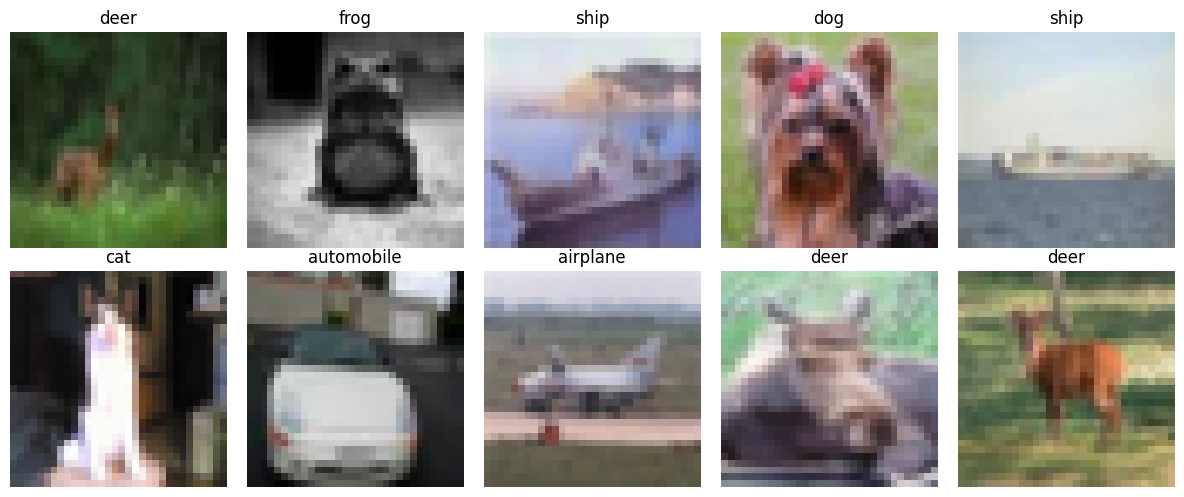

In [10]:
#pick ten random training images (using the library random) and visualize them in a grid with matplotlib
samples = random.sample(range(len(x_train)), 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i, idx in enumerate(samples):
    axes[i].imshow(x_train[idx])
    axes[i].set_title(classes[y_train[idx][0]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Now, we will initiliaze a model based on DenseNet121 (from scratch), a good trade-off between efficiency and efficacy.
We will use the library keras applications.

In [11]:
def initialize_model(num_classes, learning_rate=0.001):
    base_model = DenseNet121(weights=None, include_top=False)

    x = base_model.output

    #now, we will build the model for CIFAR10 classification

    # let's add a Global average pooling
    x = GlobalAveragePooling2D()(x)

    # let's add a fully-connected layer
    x = Dense(512, activation='relu')(x)

    # let's add the output layer
    preds = Dense(num_classes, activation='softmax')(x)

    # define the full model by linking inputs and outputs
    model = Model(inputs=base_model.input, outputs=preds)

    #initialize the optimizer
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    # Compile the model, passing the optimizer as parameter.
    # Also set the loss to be "categorical_crossentropy"
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=["accuracy"]
    )

    return model


Now, normalize input images to be floating point values between 0 and 1, then convert labels to one-hot encoding (using `keras.utils.to_categorical`). Be sure to apply normalization on both train and test data.

In [12]:
#normalize x_train
x_train = x_train/255.0
#categorize y_train
y_train = keras.utils.to_categorical(y_train)

# Do the same for the test set
x_test = x_test/255.0
y_test = keras.utils.to_categorical(y_test)

Now, create the three subsets with cardinality c1 = 2000, c2= 5000, c3 = 10000.

**tip**: we want a balanced dataset, so use stratified train test split from sklearn library (the idea will be to create a split with ${test\_size}_i = (1 - \frac{c\_i}{\vert x\_train \vert}, i=1,2,3$) discarding the test split.

In [13]:
from sklearn.model_selection import train_test_split

# for one subset
subset_sizes = [2000, 5000, 10000]
subsets = []

for size in subset_sizes:
    x_subset, _, y_subset, _ = train_test_split(x_train, y_train, train_size=size, stratify=y_train.argmax(axis=1))
    subsets.append((x_subset, y_subset))

**Initialize one model for each subset and store them, so that you can evaluate them separately**

use `model.save_weights("checkpoints/model_name.weights.h5")` to store the learned weights.

Choose a different checkpoint name for each model.


In [14]:
for i, (x_train_subset, y_train_subset) in enumerate(subsets):
    model = initialize_model(num_classes=10)
    model.fit(x_train_subset, y_train_subset, batch_size=32, epochs=20, validation_split=0.2, verbose=1)
    model.save_weights(f"checkpoints/model_subset_{i}.weights.h5")

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 258s 841ms/step - accuracy: 0.2275 - loss: 2.2731 - val_accuracy: 0.1125 - val_loss: 2.3451
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 487ms/step - accuracy: 0.3381 - loss: 1.8328 - val_accuracy: 0.1350 - val_loss: 2.5532
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 485ms/step - accuracy: 0.3925 - loss: 1.6478 - val_accuracy: 0.1350 - val_loss: 2.9897
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 482ms/step - accuracy: 0.4494 - loss: 1.5539 - val_accuracy: 0.0875 - val_loss: 3.9373
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 485ms/step - accuracy: 0.4769 - loss: 1.4552 - val_accuracy: 0.1550 - val_loss: 2.9191
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.5406 - loss: 1.3126 - val_accuracy: 0.1050 - val_loss: 2.9922
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 488ms/step - accuracy: 0.5800 - loss: 1.2050 - val_accuracy: 0.2000 - val_loss: 3.2509
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step - accuracy: 0.5994 - loss: 1.1113 - val_acc

You can load a specific model, you can use `model.load_weights("checkpoints/model_name.weights.h5")`

Evaluate each model on the whole **original** test set, computing its accuracy.

Recall that accuracy

In [15]:
model = initialize_model(num_classes=10)
model.load_weights(f"checkpoints/model_subset_0.weights.h5")
_, acc_2000 = model.evaluate(x_test, y_test, verbose=0)

model.load_weights(f"checkpoints/model_subset_1.weights.h5")
_, acc_5000 = model.evaluate(x_test, y_test, verbose=0)

model.load_weights(f"checkpoints/model_subset_2.weights.h5")
_, acc_10000 = model.evaluate(x_test, y_test, verbose=0)

print(f"Accuracy with 2000 samples: {acc_2000:.4f}")
print(f"Accuracy with 5000 samples: {acc_5000:.4f}")
print(f"Accuracy with 10000 samples: {acc_10000:.4f}")

c:\Users\Mario\Documents\UNIGE\Unige_code\Master\First\MSC_py_vem\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 734 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Accuracy with 2000 samples: 0.3320
Accuracy with 5000 samples: 0.4975
Accuracy with 10000 samples: 0.5829


Now, we will implement a rotation self-supervised pre-text task.
So:



*   Create the pre-text dataset
*   Initialize a model
*   train the model from scratch on the pre-text task



**Create the pre-text dataset**

input: a training set with no labels (x_train,), rotation_set = [0,1,2,3]

create a copy or original dataset (x_train_rotated)

create an empty vector of labels (y_train_rotated)

```
For i in range(0,len(x_train)):

    k = pick a random element of rotation set

    #look for an appropriate function in tf.image

    y_train_rotated[i] = k

```

In [16]:
# Generate random rotation labels for the entire dataset at once
y_train_rotated = np.random.randint(0, 4, len(x_train))

# Apply rotations to all images having the same "rotation label"
def rotate_batch(images, rotations):
    rotated_images = np.empty_like(images)  # Preallocate memory

    for k in range(4):  # Loop over rotation angles (0, 1, 2, 3)
        mask = rotations == k  # Boolean mask for this rotation
        rotated_images[mask] = tf.image.rot90(images[mask], k=k).numpy()  # rotates all images having the same y_train_rotated label, look for the appropriate function in tf.image

    return rotated_images

x_train_rotated = rotate_batch(x_train, y_train_rotated)



You can store and/or load your new dataset to save time and computation. You have an empty cell below to do so if you want

```python
np.save("checkpoints/x_train_rotated.npy", x_train_rotated)
np.save("checkpoints/y_train_rotated.npy", y_train_rotated)
x_train_rotated = np.load("checkpoints/x_train_rotated.npy")
y_train_rotated = np.load("checkpoints/y_train_rotated.npy")
```

In [17]:
np.save("checkpoints/x_train_rotated.npy", x_train_rotated)
np.save("checkpoints/y_train_rotated.npy", y_train_rotated)

Visualize ten random samples to verify the obtained dataset

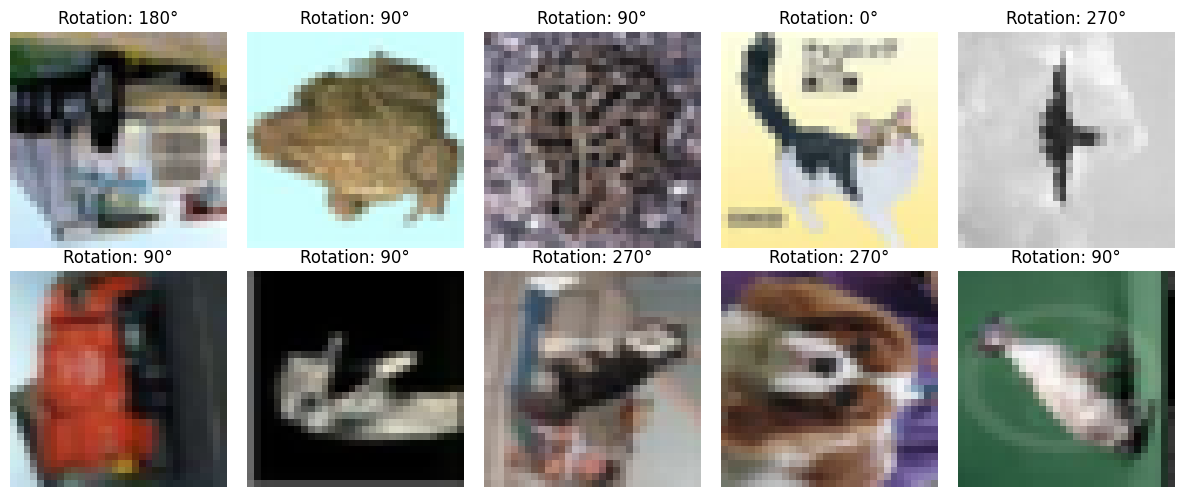

In [18]:
rotation_labels = ['0°', '90°', '180°', '270°']
samples = random.sample(range(len(x_train_rotated)), 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i, idx in enumerate(samples):
    axes[i].imshow(x_train_rotated[idx])
    axes[i].set_title(f"Rotation: {rotation_labels[y_train_rotated[idx]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Re-define a DenseNet121 model, as done before (**careful on the required number of classes**).

In [19]:
model = initialize_model(num_classes=4)

fit the model for the pre-text task

In [20]:
#normalize the images in x_train_rotated
x_train_rotated = x_train_rotated/255.0
# then convert pretext task labels (y_train_rotated) to one-hot encoding
y_train_rotated = keras.utils.to_categorical(y_train_rotated, num_classes=4)

#fit the model and store its weights, like you did before
model.fit(x_train_rotated, y_train_rotated, batch_size=32, epochs=20, validation_split=0.2, verbose=1)
model.save_weights("checkpoints/model_pretext.weights.h5")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 873s 538ms/step - accuracy: 0.5076 - loss: 1.1334 - val_accuracy: 0.5376 - val_loss: 1.0770
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 593s 475ms/step - accuracy: 0.5907 - loss: 0.9846 - val_accuracy: 0.5826 - val_loss: 1.0403
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 217s 174ms/step - accuracy: 0.6227 - loss: 0.9198 - val_accuracy: 0.5467 - val_loss: 1.2023
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 201s 161ms/step - accuracy: 0.6412 - loss: 0.8775 - val_accuracy: 0.6377 - val_loss: 0.9069
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 201s 161ms/step - accuracy: 0.6645 - loss: 0.8303 - val_accuracy: 0.6127 - val_loss: 0.9319
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 160ms/step - accuracy: 0.6868 - loss: 0.7812 - val_accuracy: 0.6271 - val_loss: 0.9561
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 160ms/step - accuracy: 0.7048 - loss: 0.7381 - val_accuracy: 0.6571 - val_loss: 0.8511
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 199s 159ms/step - ac

In [21]:
# It shows a summary of the model
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_10   │ (None, None,      │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ zero_padding2d_1… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_11   │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, None,      │          0 │ conv2_block1_0_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, None,      │          0 │ pool1[0][0],      │
│ (Concatenate)       │ None, 96)         │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, None,      │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, None,      │          0 │ conv2_block2_0_b… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, None,      │     12,288 │ conv2_block2_0_r

 Total params: 22,525,774 (85.93 MB)

 Trainable params: 7,480,708 (28.54 MB)

 Non-trainable params: 83,648 (326.75 KB)

 Optimizer params: 14,961,418 (57.07 MB)

Now, we are ready to fine-tune the model on the downstream task.

To do so:

-   Load the trained backbone of the pre-text task
-   Re-define the classification hat (with the appropriate output layer):
    + Take inspiration from the function `initialize_model`, and consider that than you can take the features of the pretext model coming out from `model.layers[-4].output`.
    + Then, add `GlobalAveragePooling2D()`, a Dense layer with 512 neurons + `relu` activation, and a prediction layer with the correct number of outputs and softmax activation
-   Re-train (use a lower learning rate than training from scratch)



In [22]:
model.load_weights("checkpoints/model_pretext.weights.h5")
x = model.layers[-4].output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
preds = Dense(10, activation='softmax')(x)
model = Model(inputs=model.input, outputs=preds)

# Initialize the optimizer with a learning rate of 0.00001
optimizer = keras.optimizers.Adam(learning_rate=0.00001)

# Compile the model as done in "initialize_model" function
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=["accuracy"])

# Fit the model on the subset
x_train_subset, y_train_subset = subsets[0]
model.fit(x_train_subset, y_train_subset, batch_size=32, epochs=20, validation_split=0.2, verbose=1)

# Save the model
model.save_weights("checkpoints/model_ssl_2000.weights.h5")

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 138s 475ms/step - accuracy: 0.1200 - loss: 2.3483 - val_accuracy: 0.1200 - val_loss: 2.3737
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 299ms/step - accuracy: 0.1725 - loss: 2.2222 - val_accuracy: 0.1650 - val_loss: 2.1950
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.2163 - loss: 2.1456 - val_accuracy: 0.2375 - val_loss: 2.0983
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - accuracy: 0.2488 - loss: 2.0904 - val_accuracy: 0.2725 - val_loss: 2.0386
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 275ms/step - accuracy: 0.2837 - loss: 2.0479 - val_accuracy: 0.2850 - val_loss: 2.0040
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 312ms/step - accuracy: 0.2944 - loss: 2.0113 - val_accuracy: 0.2900 - val_loss: 1.9740
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.3006 - loss: 1.9753 - val_accuracy: 0.2875 - val_loss: 1.9482
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 329ms/step - accuracy: 0.3212 - loss: 1.9460 - val_acc

In [24]:
#evaluate the model on the whole original test set
_, acc_ssl_2000 = model.evaluate(x_test, y_test, verbose=0)
print(f"SSL Accuracy with 2000 samples: {acc_ssl_2000:.4f}")

# Fine-tune on 5000 samples
model.load_weights("checkpoints/model_pretext.weights.h5")
x = model.layers[-4].output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
preds = Dense(10, activation='softmax')(x)
model = Model(inputs=model.input, outputs=preds)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=["accuracy"])

x_train_subset, y_train_subset = subsets[1]
model.fit(x_train_subset, y_train_subset, batch_size=32, epochs=20, validation_split=0.2, verbose=1)
model.save_weights("checkpoints/model_ssl_5000.weights.h5")
_, acc_ssl_5000 = model.evaluate(x_test, y_test, verbose=0)
print(f"SSL Accuracy with 5000 samples: {acc_ssl_5000:.4f}")

# Fine-tune on 10000 samples
model.load_weights("checkpoints/model_pretext.weights.h5")
x = model.layers[-4].output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
preds = Dense(10, activation='softmax')(x)
model = Model(inputs=model.input, outputs=preds)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=["accuracy"])

x_train_subset, y_train_subset = subsets[2]
model.fit(x_train_subset, y_train_subset, batch_size=32, epochs=20, validation_split=0.2, verbose=1)
model.save_weights("checkpoints/model_ssl_10000.weights.h5")
_, acc_ssl_10000 = model.evaluate(x_test, y_test, verbose=0)
print(f"SSL Accuracy with 10000 samples: {acc_ssl_10000:.4f}")

SSL Accuracy with 2000 samples: 0.1263


ValueError: A total of 2 objects could not be loaded. Example error message for object <Dense name=dense_13, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(512, 10), Received: value.shape=(512, 4). Target variable: <Variable path=dense_13/kernel, shape=(512, 10), dtype=float32, value=[[ 0.02249745 -0.06896128 -0.00140889 ... -0.01327485 -0.03675248
  -0.00649286]
 [ 0.05049383 -0.02332122  0.02763774 ... -0.10478867  0.09142902
  -0.00883987]
 [ 0.08469199 -0.01966701 -0.04057575 ...  0.0990163   0.09082381
  -0.02007567]
 ...
 [ 0.06010933  0.07782807 -0.00610634 ... -0.0690719   0.06551328
  -0.08078452]
 [-0.01239597  0.08213612 -0.02525901 ... -0.10099756  0.06767452
   0.00021082]
 [-0.01020367  0.0829675  -0.06663491 ... -0.04623511 -0.03056403
   0.05847834]]>

List of objects that could not be loaded:
[<Dense name=dense_13, built=True>, <keras.src.optimizers.adam.Adam object at 0x000002FB7

Make a plot of (scratch_accuracy and SSL_accuracy) with the three different subset sizes.

Do you get any benefit on the downstream task, with self-supervision?

Comment on the results

In [ ]:
scratch_accuracies = [acc_2000, acc_5000, acc_10000]
ssl_accuracies = [acc_ssl_2000, acc_ssl_5000, acc_ssl_10000]

plt.figure(figsize=(10, 6))
plt.plot(subset_sizes, scratch_accuracies, 'o-', label='Training from Scratch', linewidth=2, markersize=8)
plt.plot(subset_sizes, ssl_accuracies, 's-', label='Self-Supervised Learning', linewidth=2, markersize=8)
plt.xlabel('Number of Training Samples')
plt.ylabel('Test Accuracy')
plt.title('Performance Comparison: Scratch vs Self-Supervised Learning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(subset_sizes)
plt.show()

print("\nPerformance Improvement:")
for i, size in enumerate(subset_sizes):
    improvement = (ssl_accuracies[i] - scratch_accuracies[i]) * 100
    print(f"  {size} samples: {improvement:+.2f}% absolute improvement")

**Optional** If you have time, you can repeat the previous experiments also with the full dataset.


In [ ]:
# Optional: Train on full dataset from scratch
model_scratch_full = initialize_model(num_classes=10)
model_scratch_full.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2, verbose=1)
_, acc_scratch_full = model_scratch_full.evaluate(x_test, y_test, verbose=0)
print(f"Full dataset accuracy (from scratch): {acc_scratch_full:.4f}")

# Optional: Fine-tune SSL model on full dataset
model_ssl_full = initialize_model(num_classes=4)
model_ssl_full.load_weights("checkpoints/model_pretext.weights.h5")
x = model_ssl_full.layers[-4].output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
preds = Dense(10, activation='softmax')(x)
model_ssl_full = Model(inputs=model_ssl_full.input, outputs=preds)
model_ssl_full.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=["accuracy"])

model_ssl_full.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2, verbose=1)
_, acc_ssl_full = model_ssl_full.evaluate(x_test, y_test, verbose=0)
print(f"Full dataset accuracy (SSL): {acc_ssl_full:.4f}")